# Amazon Sales: Exploratory Data Analysis

**Dataset Overview:**

The [Amazon Sales Dataset](https://www.kaggle.com/datasets/karkavelrajaj/amazon-sales-dataset) contains over 1,000 observations of e-commerce sales data scraped from Amazon. Each observation represents a purchase made, with corresponding features about product, transaction, and review data. Specifically, this dataset will be utilized to develop a model for predicting product ratings using a supervised learning approach, which is useful for extracting the drivers of customer satisfaction.

## Load Dataset and Dependencies

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import utils

sns.set_theme(style="dark")

In [2]:
df_raw = pd.read_csv("data/amazon.csv")
df_raw.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Initial Data Inspection

In [3]:
rows, cols = df_raw.shape

print("Number of rows:", rows)
print("Number of columns:", cols)

Number of rows: 1465
Number of columns: 16


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

## Data Cleaning

### Summary of Issues Identified

**Duplicates**
- There are no duplicated rows.

**Irrelevant Columns/Features**
- `product_id`, `user_id`, `review_id` are not needed because they only serve as identifiers.
- `product_name` is not relevant to analysis since it just identifies the product through name.
- `user_name` should not be included since this is personally identifiable information (PII).
- `about_product`, `review_title`, and `review_content` are unstructured text features and would not be needed for EDA.
    - **NOTE:** These features could be used in the modeling stage if preprocessing is applied to extract embeddings.
- `img_link` and `product_link` can be excluded as they are just URLs pointing to the source of data.

**Data Type Issues**
- `discounted_price`, `actual_price`, `discount_percentage`, `rating`, and `rating_count` are currently stored as `object` and should be converted to numeric dtype.
- `category` is currently stored as `object` and should be converted to `category` dtype.

**Formatting Issues**
- `category` values are too granular due to their deeply nested hierarchical structure, leading to high cardinality. It would be better to extract their general category label and reformat the values to become more readable.
- `discounted_price`, `actual_price`, and `discount_percentage` have unnecessary symbols (e.g., `₹`, `%`, `,`) and could be the cause why these columns are stored as `object` dtype.
- `discount_percentage` should be in decimal format: `(64% -> 0.64)`

**Incorrect/Erroneous Values**
- `rating` has one record containing `|`.

**Missing Values**
- `rating_count` - 2 missing
- `rating` - 1 missing (Formatted as empty string instead of `NaN`, due to the incorrect value mentioned above)

**Data Range Issues**
- There are no out of range values across each numerical column.

**Outliers**
- Using the IQR method, outliers have been identified in the following columns:
    - `discounted_price` - 217 outliers
    - `actual_price` - 213 outliers
    - `rating` - 74 outliers
    - `rating_count` - 141 outliers

In [5]:
# Check for duplicate records
num_dups = df_raw.duplicated().sum()
print("Number of duplicate records:", num_dups)

Number of duplicate records: 0


In [6]:
# Check for incorrect data types
df_raw.dtypes

product_id             object
product_name           object
category               object
discounted_price       object
actual_price           object
discount_percentage    object
rating                 object
rating_count           object
about_product          object
user_id                object
user_name              object
review_id              object
review_title           object
review_content         object
img_link               object
product_link           object
dtype: object

Based on the result above, we can observe that all columns are stored as `object` dtype, even columns that are expected to be numeric (`discounted_price`, `actual_price`, `discount_percentage`, `rating`, `rating_count`) are of `object` type. We can further investigate these specific columns by inspecting their values to figure out why. 

In [7]:
# Check formatting issues on the should-be numeric columns
num_cols = ["discounted_price", "actual_price", "discount_percentage", "rating", "rating_count"]
df_raw[num_cols].head()

,discounted_price,actual_price,discount_percentage,rating,rating_count
0,₹399,"₹1,099",64%,4.2,"24,269"
1,₹199,₹349,43%,4.0,"43,994"
2,₹199,"₹1,899",90%,3.9,"7,928"
3,₹329,₹699,53%,4.2,"94,363"
4,₹154,₹399,61%,4.2,"16,905"


As we can see, `discounted_price` and `actual_price` have currency symbols (`₹`); `discount_percentage` has `%` at the end; the aforementioned currency columns and `rating_count` contain `,`. The presence of these special characters are the reason why these columns cannot be stored as numeric. However, `rating` does not have issues with unnecessary characters and is just stored as `object`.

In [8]:
# Check for missing values
print("Missing values per column:")
df_raw.isna().sum()

Missing values per column:


product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [9]:
# Check for incorrect/erroneous values (only included relevant columns to the task)
# Uncomment one at a time when checking

# df_raw["category"].unique().tolist()
# df_raw["discounted_price"].unique().tolist()
# df_raw["actual_price"].unique().tolist()
# df_raw["discount_percentage"].unique().tolist()
# df_raw["rating_count"].unique().tolist()
df_raw["rating"].unique().tolist()

['4.2',
 '4.0',
 '3.9',
 '4.1',
 '4.3',
 '4.4',
 '4.5',
 '3.7',
 '3.3',
 '3.6',
 '3.4',
 '3.8',
 '3.5',
 '4.6',
 '3.2',
 '5.0',
 '4.7',
 '3.0',
 '2.8',
 '4',
 '3.1',
 '4.8',
 '2.3',
 '|',
 '2',
 '3',
 '2.6',
 '2.9']

After running each command above, only the `rating` column contained an unexpected/erroneous value, which is `|`. To treat this, we will flag any values containing non-numeric values as errors and replace them with `NaN` so that they can be handled along with other missing values.

In [10]:
# Check structure of `category` to guide in creating broader classes
df_raw["category"].unique().tolist()[:10]

['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
 'Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters',
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables',
 'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions',
 'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls',
 'Electronics|HomeTheater,TV&Video|Televisions|StandardTelevisions',
 'Electronics|HomeTheater,TV&Video|Accessories|TVMounts,Stands&Turntables|TVWall&CeilingMounts',
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|RCACables',
 'Electronics|HomeAudio|Accessories|SpeakerAccessories|Mounts',
 'Electronics|HomeTheater,TV&Video|Accessories|Cables|OpticalCables']

In [11]:
print(f"Count of unique categories: {df_raw["category"].nunique()}")

Count of unique categories: 211


As we can observe, the `category` values seem to be structured as hierarchical, starting from the top-level category (e.g., "Electronics") with multiple nestings of sub-categories. Additionally, there are `211` unique categories, which is a significantly high cardinality and the model can be negatively impacted by the _Curse of Dimensionality_. This can lead to too many dimensions when categorical columns are encoded, which can cause increased computational cost and performance issues for models sensitive to high-dimensional data.

Therefore, it would be better to consolidate related sub-categories into their broader top-level categories to decrease cardinality so that the issues above can be avoided.

### Fixing the Issues

In [12]:
# Create copy to store cleaned data
df_clean = df_raw.copy()

# Drop irrelevant columns
cols_to_drop = ["product_id", "user_id", "review_id", "user_name", "product_name", 
                "about_product", "review_title", "review_content", "img_link", "product_link"]

df_clean.drop(columns=cols_to_drop, inplace=True)

# Remove unnecessary characters (particularly currency symbols and commas)
for col in num_cols:
    df_clean[col] = df_clean[col].str.replace(r"[^\d.]", "", regex=True) # This regex only keeps digits and dots

# Convert columns to numeric
df_clean[num_cols] = df_clean[num_cols].apply(pd.to_numeric, errors="coerce")

# Convert `discount_percentage` to range 0-1 (64 -> 0.64)
df_clean["discount_percentage"] = df_clean["discount_percentage"] / 100

# Consolidate original categories into generalizable classes
df_clean["category"] = df_clean["category"].str.split("|").str[0]

# Reformat category names to be more readable
df_clean["category"] = df_clean["category"].str.replace("&", " & ")

# Convert to category dtype
df_clean["category"] = df_clean["category"].astype("category")

# Inspect remapped categories
print(f"Number of categories: {df_clean["category"].nunique()}")
df_clean["category"].value_counts()

Number of categories: 9


category
Electronics                526
Computers & Accessories    453
Home & Kitchen             448
OfficeProducts              31
HomeImprovement              2
MusicalInstruments           2
Car & Motorbike              1
Health & PersonalCare        1
Toys & Games                 1
Name: count, dtype: int64

In [13]:
df_clean.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,Computers & Accessories,399.0,1099.0,0.64,4.2,24269.0
1,Computers & Accessories,199.0,349.0,0.43,4.0,43994.0
2,Computers & Accessories,199.0,1899.0,0.90,3.9,7928.0
3,Computers & Accessories,329.0,699.0,0.53,4.2,94363.0
4,Computers & Accessories,154.0,399.0,0.61,4.2,16905.0


In [14]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   category             1465 non-null   category
 1   discounted_price     1465 non-null   float64 
 2   actual_price         1465 non-null   float64 
 3   discount_percentage  1465 non-null   float64 
 4   rating               1464 non-null   float64 
 5   rating_count         1463 non-null   float64 
dtypes: category(1), float64(5)
memory usage: 59.1 KB


**NOTE:** After cleaning the numerical columns, an additional missing value was found in the `rating` column.

In [15]:
df_clean.isna().sum()

category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
dtype: int64

In [16]:
# Check for out of range data
df_clean.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1465.000000,1465.000000,1465.000000,1464.000000,1463.000000
mean,3125.310874,5444.990635,0.476915,4.096585,18295.541353
std,6944.304394,10874.826864,0.216359,0.291674,42753.864952
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,0.320000,4.000000,1186.000000
50%,799.000000,1650.000000,0.500000,4.100000,5179.000000
75%,1999.000000,4295.000000,0.630000,4.300000,17336.500000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000


Based on the `min` and `max` values, there are no signs of out of range data across all numerical features.

Before fixing missing values, we must first investigate the data further before deciding on a solution.

In [17]:
# Inspect rows with missing values
df_clean[df_clean.isna().any(axis=1)].head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count
282,Computers & Accessories,199.0,999.0,0.80,3.0,NaN
324,Computers & Accessories,249.0,999.0,0.75,5.0,NaN
1279,Home & Kitchen,2099.0,2499.0,0.16,NaN,992.0


Since `rating` will be the prediction target, and there is only a single row affected, missing values from this column can be dropped to ensure data integrity of the ground truth.

In [18]:
df_clean.dropna(subset="rating", inplace=True)

df_clean.isna().sum()

category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
dtype: int64

For handling missing values in `rating_count`, **imputation** will be used to fill in nulls with a substitute value (mean or median), and preserves data size by avoiding dropping rows that could still hold predictive power. To determine which method to use, we must first investigate the distribution of the data since mean imputation is sensitive to skewed data.  

In [19]:
df_clean["rating_count"].describe()

count      1462.000000
mean      18307.376881
std       42766.096572
min           2.000000
25%        1191.500000
50%        5179.000000
75%       17342.250000
max      426973.000000
Name: rating_count, dtype: float64

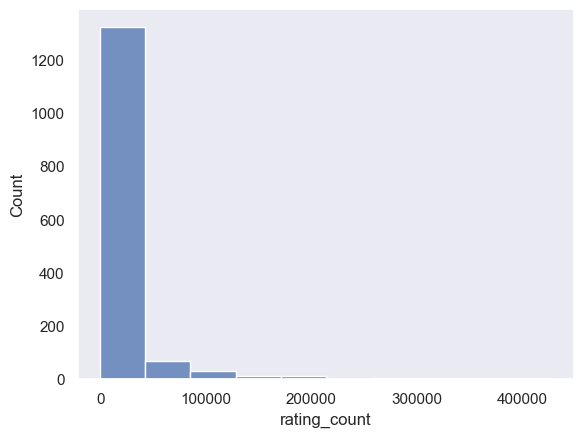

In [20]:
sns.histplot(data=df_clean, x="rating_count", bins=10)
plt.show()

Based on both descriptive statistics and visualization, the `rating_count` column is right-skewed and it would be preferred to use the **median** for imputing missing values since it is less sensitive to outliers compared to using the mean.

In [21]:
rating_count_median = df_clean["rating_count"].median()

df_clean["rating_count"] = df_clean["rating_count"].fillna(rating_count_median)

df_clean.isna().sum()

category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
dtype: int64

In [22]:
# Check for outliers (Use IQR method)
# `num_cols` was already defined earlier
for col in num_cols:
    outliers = utils.find_outliers(df_clean, col)
    count_outliers = len(outliers)
    print(f"Count of outliers: {count_outliers}\n")

Column: discounted_price
Lower bound: -2189.125
Upper bound: 4511.875
Count of outliers: 217

Column: actual_price
Lower bound: -4455.625
Upper bound: 9559.375
Count of outliers: 213

Column: discount_percentage
Lower bound: -0.14499999999999996
Upper bound: 1.095
Count of outliers: 0

Column: rating
Lower bound: 3.5500000000000003
Upper bound: 4.75
Count of outliers: 74

Column: rating_count
Lower bound: -23014.875
Upper bound: 41538.125
Count of outliers: 141



Since there are several outliers across three of the numerical columns, we must first investigate these instances to inform how to handle them properly.

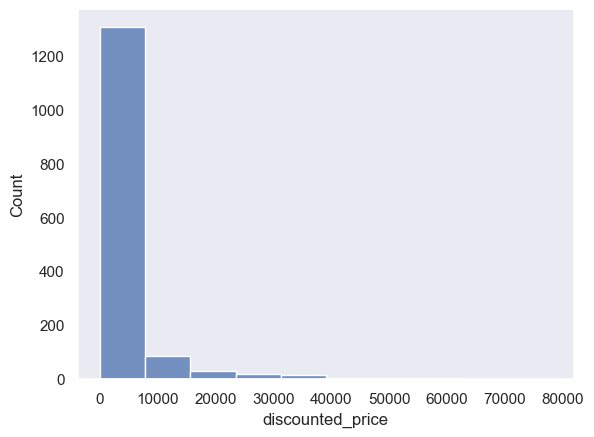

In [23]:
sns.histplot(data=df_clean, x="discounted_price", bins=10)
plt.show()

In [24]:
utils.find_outliers(df_clean, "discounted_price")

Column: discounted_price
Lower bound: -2189.125
Upper bound: 4511.875


,category,discounted_price,actual_price,discount_percentage,rating,rating_count
16,Electronics,13999.0,24999.0,0.44,4.2,32840.0
19,Electronics,13490.0,21990.0,0.39,4.3,11976.0
22,Electronics,13490.0,22900.0,0.41,4.3,16299.0
24,Electronics,11499.0,19990.0,0.42,4.3,4703.0
26,Electronics,14999.0,19999.0,0.25,4.2,34899.0
...,...,...,...,...,...,...
1428,Home & Kitchen,6120.0,8073.0,0.24,4.6,2751.0
1430,Home & Kitchen,18999.0,29999.0,0.37,4.1,2536.0
1432,Home & Kitchen,5999.0,11495.0,0.48,4.3,534.0
1437,Home & Kitchen,6199.0,10999.0,0.44,4.2,10429.0


In [25]:
df_clean[df_clean["discounted_price"] > 20000]

,category,discounted_price,actual_price,discount_percentage,rating,rating_count
38,Electronics,32999.0,45999.0,0.28,4.2,7298.0
61,Electronics,32990.0,47900.0,0.31,4.3,7109.0
72,Electronics,26999.0,42999.0,0.37,4.2,45238.0
85,Electronics,29999.0,39999.0,0.25,4.2,7298.0
86,Electronics,27999.0,40990.0,0.32,4.3,4703.0
87,Electronics,30990.0,52900.0,0.41,4.3,7109.0
91,Electronics,24999.0,31999.0,0.22,4.2,34899.0
103,Electronics,21999.0,29999.0,0.27,4.2,32840.0
108,Electronics,37999.0,65000.0,0.42,4.3,3587.0
123,Electronics,20990.0,44990.0,0.53,4.1,1259.0


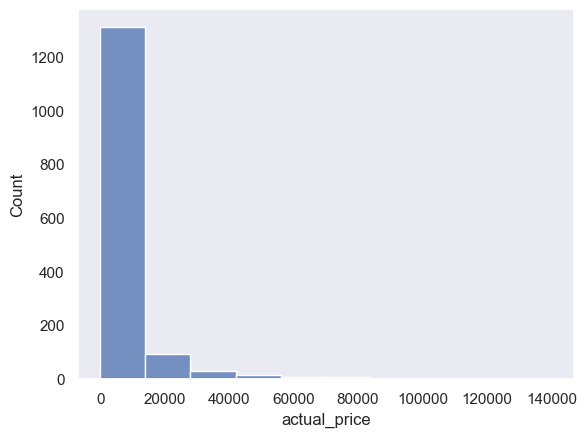

In [26]:
sns.histplot(data=df_clean, x="actual_price", bins=10)
plt.show()

In [27]:
utils.find_outliers(df_clean, "actual_price")

Column: actual_price
Lower bound: -4455.625
Upper bound: 9559.375


,category,discounted_price,actual_price,discount_percentage,rating,rating_count
16,Electronics,13999.0,24999.0,0.44,4.2,32840.0
19,Electronics,13490.0,21990.0,0.39,4.3,11976.0
22,Electronics,13490.0,22900.0,0.41,4.3,16299.0
24,Electronics,11499.0,19990.0,0.42,4.3,4703.0
26,Electronics,14999.0,19999.0,0.25,4.2,34899.0
...,...,...,...,...,...,...
1416,Home & Kitchen,4999.0,24999.0,0.80,4.5,287.0
1430,Home & Kitchen,18999.0,29999.0,0.37,4.1,2536.0
1432,Home & Kitchen,5999.0,11495.0,0.48,4.3,534.0
1437,Home & Kitchen,6199.0,10999.0,0.44,4.2,10429.0


In [28]:
df_clean[df_clean["actual_price"] > 40000]

,category,discounted_price,actual_price,discount_percentage,rating,rating_count
38,Electronics,32999.0,45999.0,0.28,4.2,7298.0
61,Electronics,32990.0,47900.0,0.31,4.3,7109.0
72,Electronics,26999.0,42999.0,0.37,4.2,45238.0
86,Electronics,27999.0,40990.0,0.32,4.3,4703.0
87,Electronics,30990.0,52900.0,0.41,4.3,7109.0
94,Electronics,18990.0,40990.0,0.54,4.2,6659.0
108,Electronics,37999.0,65000.0,0.42,4.3,3587.0
123,Electronics,20990.0,44990.0,0.53,4.1,1259.0
124,Electronics,32999.0,44999.0,0.27,4.2,45238.0
135,Electronics,30990.0,49990.0,0.38,4.3,1376.0


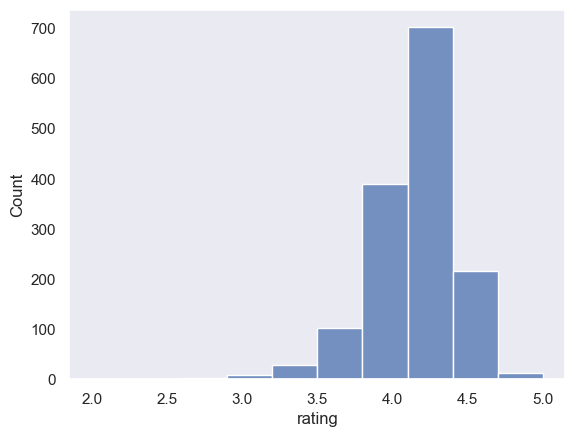

In [29]:
sns.histplot(data=df_clean, x="rating", bins=10)
plt.show()

In [30]:
utils.find_outliers(df_clean, "rating")

Column: rating
Lower bound: 3.5500000000000003
Upper bound: 4.75


,category,discounted_price,actual_price,discount_percentage,rating,rating_count
45,Computers & Accessories,333.0,999.0,0.67,3.3,9792.0
82,Electronics,7299.0,19125.0,0.62,3.4,902.0
117,Computers & Accessories,347.0,999.0,0.65,3.5,1121.0
142,Electronics,655.0,1099.0,0.40,3.2,285.0
154,Computers & Accessories,249.0,399.0,0.38,3.4,4642.0
...,...,...,...,...,...,...
1446,Home & Kitchen,1149.0,1899.0,0.39,3.5,24.0
1449,Home & Kitchen,199.0,699.0,0.72,2.9,159.0
1454,Home & Kitchen,1563.0,3098.0,0.50,3.5,2283.0
1456,Home & Kitchen,498.0,1200.0,0.59,3.2,113.0


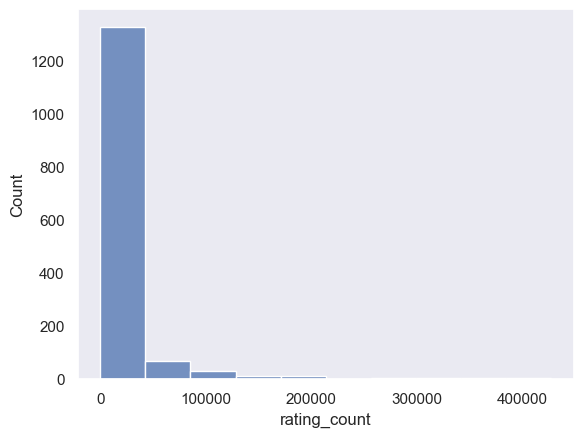

In [31]:
sns.histplot(data=df_clean, x="rating_count", bins=10)
plt.show()

In [32]:
utils.find_outliers(df_clean, "rating_count")

Column: rating_count
Lower bound: -23014.875
Upper bound: 41538.125


,category,discounted_price,actual_price,discount_percentage,rating,rating_count
1,Computers & Accessories,199.0,349.0,0.43,4.0,43994.0
3,Computers & Accessories,329.0,699.0,0.53,4.2,94363.0
8,Computers & Accessories,499.0,999.0,0.50,4.2,179691.0
9,Computers & Accessories,199.0,299.0,0.33,4.0,43994.0
11,Computers & Accessories,299.0,799.0,0.63,4.2,94363.0
...,...,...,...,...,...,...
1032,Home & Kitchen,1699.0,3193.0,0.47,3.8,54032.0
1045,Home & Kitchen,1299.0,3500.0,0.63,3.8,44050.0
1077,Home & Kitchen,775.0,875.0,0.11,4.2,46647.0
1130,Home & Kitchen,3249.0,6295.0,0.48,3.9,43070.0


In [33]:
df_clean[df_clean["rating_count"] > 100000]

,category,discounted_price,actual_price,discount_percentage,rating,rating_count
8,Computers & Accessories,499.0,999.0,0.50,4.2,179691.0
12,Electronics,219.0,700.0,0.69,4.4,426973.0
40,Computers & Accessories,209.0,695.0,0.70,4.5,107687.0
47,Electronics,309.0,475.0,0.35,4.4,426973.0
56,Computers & Accessories,649.0,1399.0,0.54,4.2,179691.0
65,Electronics,309.0,1400.0,0.78,4.4,426973.0
143,Computers & Accessories,749.0,1339.0,0.44,4.2,179692.0
191,Computers & Accessories,709.0,1999.0,0.65,4.1,178817.0
337,Electronics,2049.0,2199.0,0.07,4.3,178912.0
345,Electronics,1299.0,1599.0,0.19,4.0,128311.0


Based on both statistical and visual investigation, all data points that were identified as outliers did not demonstrate any erroneous values nor possible data entry issues. The probable cause of these anomalies could be that the majority of values are concentrated on a narrow range (as seen in the histograms). Therefore, the verdict is to **keep all outliers** as they contain genuine values and removing them would just cause significant data loss.

In [34]:
# Inspect cleaned data
df_clean.head()

,category,discounted_price,actual_price,discount_percentage,rating,rating_count
0,Computers & Accessories,399.0,1099.0,0.64,4.2,24269.0
1,Computers & Accessories,199.0,349.0,0.43,4.0,43994.0
2,Computers & Accessories,199.0,1899.0,0.90,3.9,7928.0
3,Computers & Accessories,329.0,699.0,0.53,4.2,94363.0
4,Computers & Accessories,154.0,399.0,0.61,4.2,16905.0


In [35]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1464 entries, 0 to 1464
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   category             1464 non-null   category
 1   discounted_price     1464 non-null   float64 
 2   actual_price         1464 non-null   float64 
 3   discount_percentage  1464 non-null   float64 
 4   rating               1464 non-null   float64 
 5   rating_count         1464 non-null   float64 
dtypes: category(1), float64(5)
memory usage: 70.4 KB


## Data Analysis and Visualization

### Descriptive Statistics

#### Numerical Features

In [36]:
# Display summary statistics
df_clean.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1464.000000,1464.000000,1464.000000,1464.000000,1464.000000
mean,3126.011906,5447.002923,0.477131,4.096585,18289.441940
std,6946.625442,10878.270001,0.216274,0.291674,42739.607548
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,323.750000,800.000000,0.320000,4.000000,1192.500000
50%,799.000000,1650.000000,0.500000,4.100000,5179.000000
75%,1999.000000,4303.750000,0.630000,4.300000,17330.750000
max,77990.000000,139900.000000,0.940000,5.000000,426973.000000


In [37]:
# Diplay measures of shape
df_clean[num_cols].agg(['skew', 'kurtosis'])

,discounted_price,actual_price,discount_percentage,rating,rating_count
skew,4.450677,4.558126,-0.291926,-1.242895,5.676011
kurtosis,25.623149,29.700709,-0.577256,4.359520,40.383209


**Key Findings:**

- `discounted_price`
    - In terms of measures of center, the mean is **3126.01** while the median is **799.0**, wherein the mean is substantially larger than the median. This indicates that this column has a skewed distribution, which is validated by the results of the computed skewness and kurtosis values. 
    - In terms of measures of shape, the skewness of **4.45** indicates that the data has a high positive skew, where the majority of discounted prices are low values, but the presence of outliers creates a long tail of signicantly higher values that pull the mean towards it. Furthermore, the kurtosis of *25.62* is considered as leptokurtic, which means that the distribution has a sharp peak and long tails. This means that the majority of values are clustered closely around the median and that there are more extreme values present in this column compared to the normal distribution.
    - In terms of measures of spread, the values range from a minimum of **39.0** to a maximum of **77990.0**, which demonstrates an extremely wide range of the data. This is further supported by the standard deviation of **6946.63**, which is larger than both the mean and median, indicates that the data has high variability.  

*TODO: For now, just write the key stats, but discuss them just like the first example for the final output*  

- `actual_price`
    - Mean: 5447.0
    - Median: 1650.0
    - Standard Deviation: 10878.27
    - Min: 39.0
    - Max: 139900.0
    - Skew: 4.56
    - Kurtosis: 29.70

- `discount_percentage`
    - Mean: 0.48
    - Median: 0.5
    - Standard Deviation: 0.22
    - Min: 0.0
    - Max: 0.94
    - Skew: -0.29
    - Kurtosis: -0.58

- `rating`
    - Mean: 4.1
    - Median: 4.1
    - Standard Deviation: 0.29
    - Min: 2.0
    - Max: 5.0
    - Skew: -1.24
    - Kurtosis: 4.36
  
- `rating_count`
    - Mean: 18289.44
    - Median: 5179.0
    - Standard Deviation: 42739.61
    - Min: 2.0
    - Max: 426973.0
    - Skew: 5.68
    - Kurtosis: 40.38

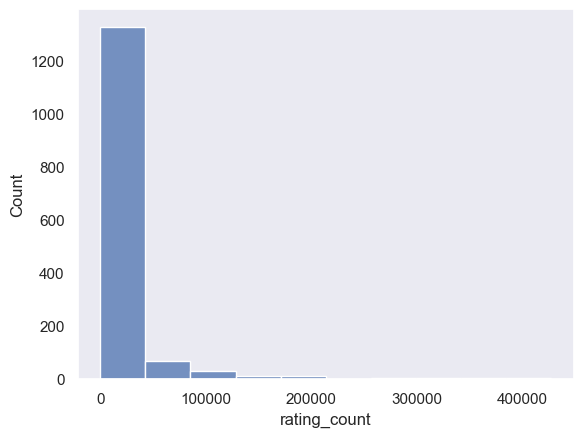

In [38]:
sns.histplot(data=df_clean, x="rating_count", bins=10)
plt.show()

#### Categorical Features

In [39]:
# Display summary statistics
df_clean["category"].describe()

count            1464
unique              9
top       Electronics
freq              526
Name: category, dtype: object

In [40]:
# Frequency table for categorical feature (counts)
df_clean["category"].value_counts()

category
Electronics                526
Computers & Accessories    453
Home & Kitchen             447
OfficeProducts              31
HomeImprovement              2
MusicalInstruments           2
Car & Motorbike              1
Health & PersonalCare        1
Toys & Games                 1
Name: count, dtype: int64

In [41]:
# Frequency table for categorical feature (proportions)
df_clean["category"].value_counts(normalize=True)

category
Electronics                0.359290
Computers & Accessories    0.309426
Home & Kitchen             0.305328
OfficeProducts             0.021175
HomeImprovement            0.001366
MusicalInstruments         0.001366
Car & Motorbike            0.000683
Health & PersonalCare      0.000683
Toys & Games               0.000683
Name: proportion, dtype: float64

**Findings:**

- The dataset is dominated by the top three categories, namely:
    1. `Electronics` - 526 records (36%)
    2. `Computers & Accessories` - 453 records (31%)
    3. `Home & Kitchen` - 447 records (31%)
- There are categories with extremely low representation (single digit counts):
  - `Car & Motorbike`, `Health & PersonalCare`, `Toys & Games` - 1 record each (0.07%)
  - `HomeImprovement`, `MusicalInstruments` - 2 records each (0.14%)
- The findings above indicate that there is severe class imbalance present within the data, which could lead to biases towards the top three categories and affect the performance of the model on underrepresented classes.

### Univariate Analysis

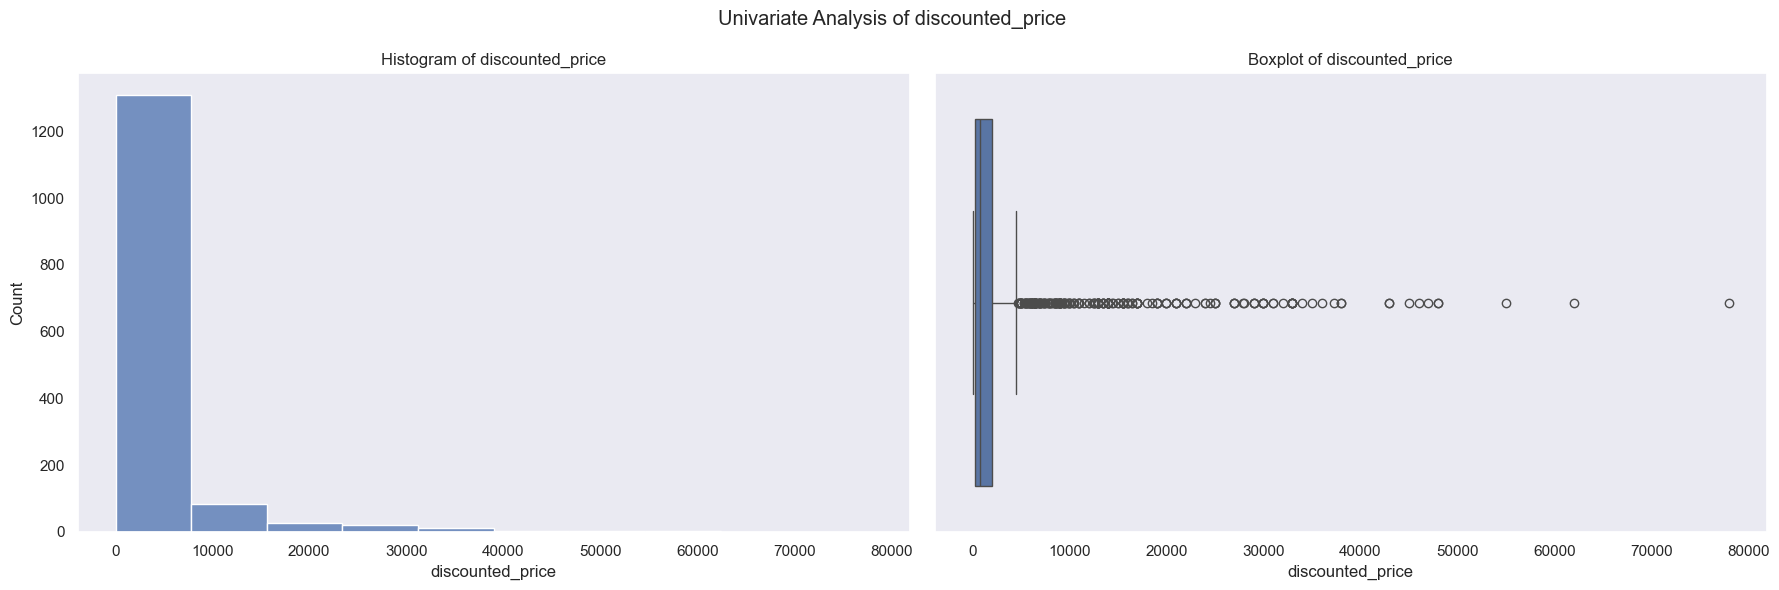

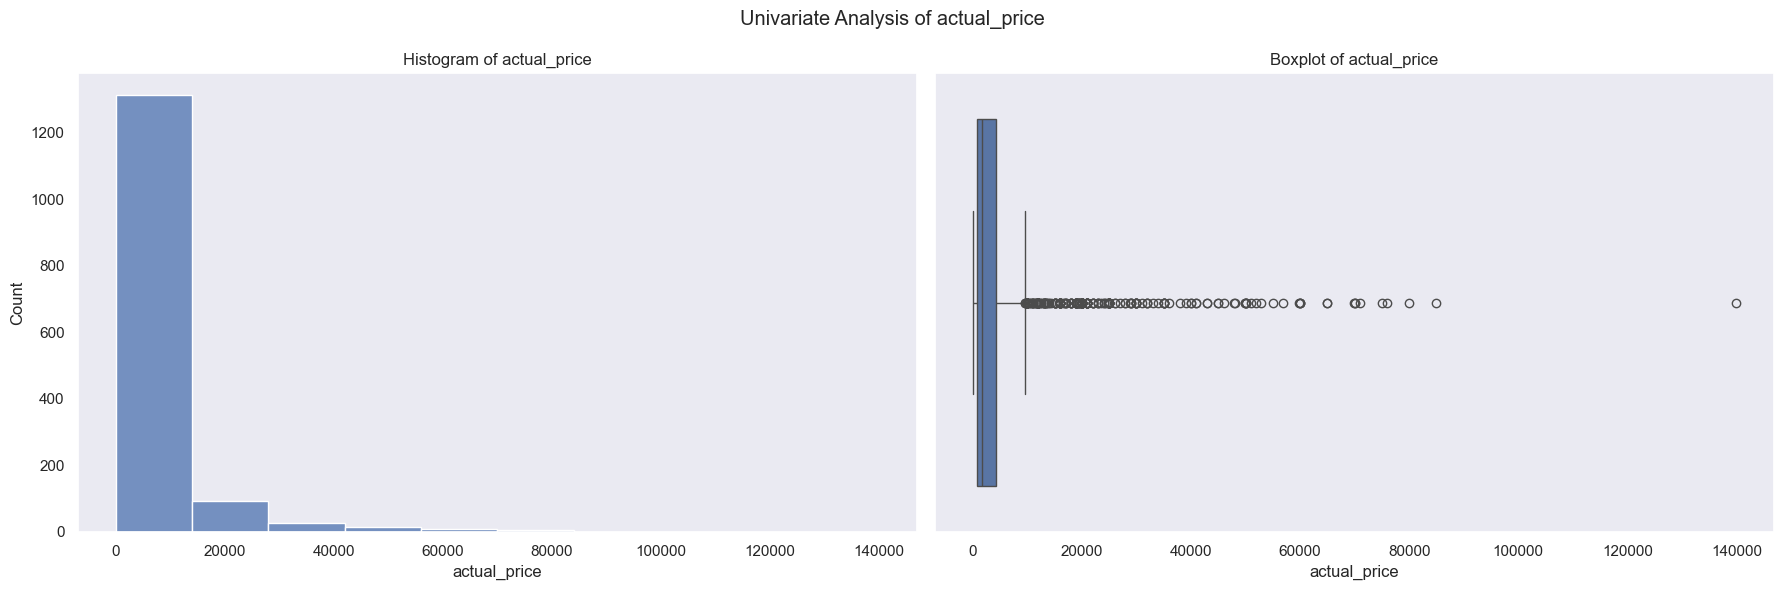

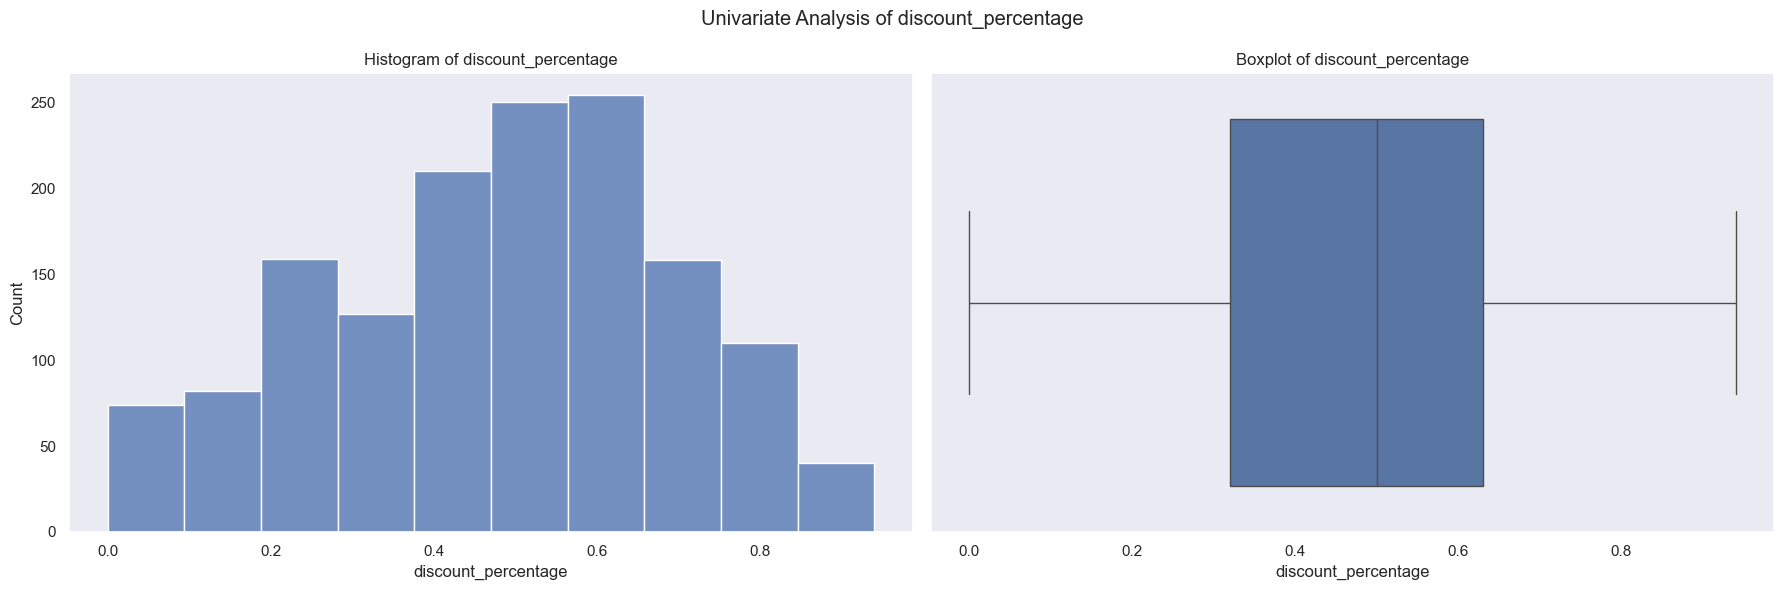

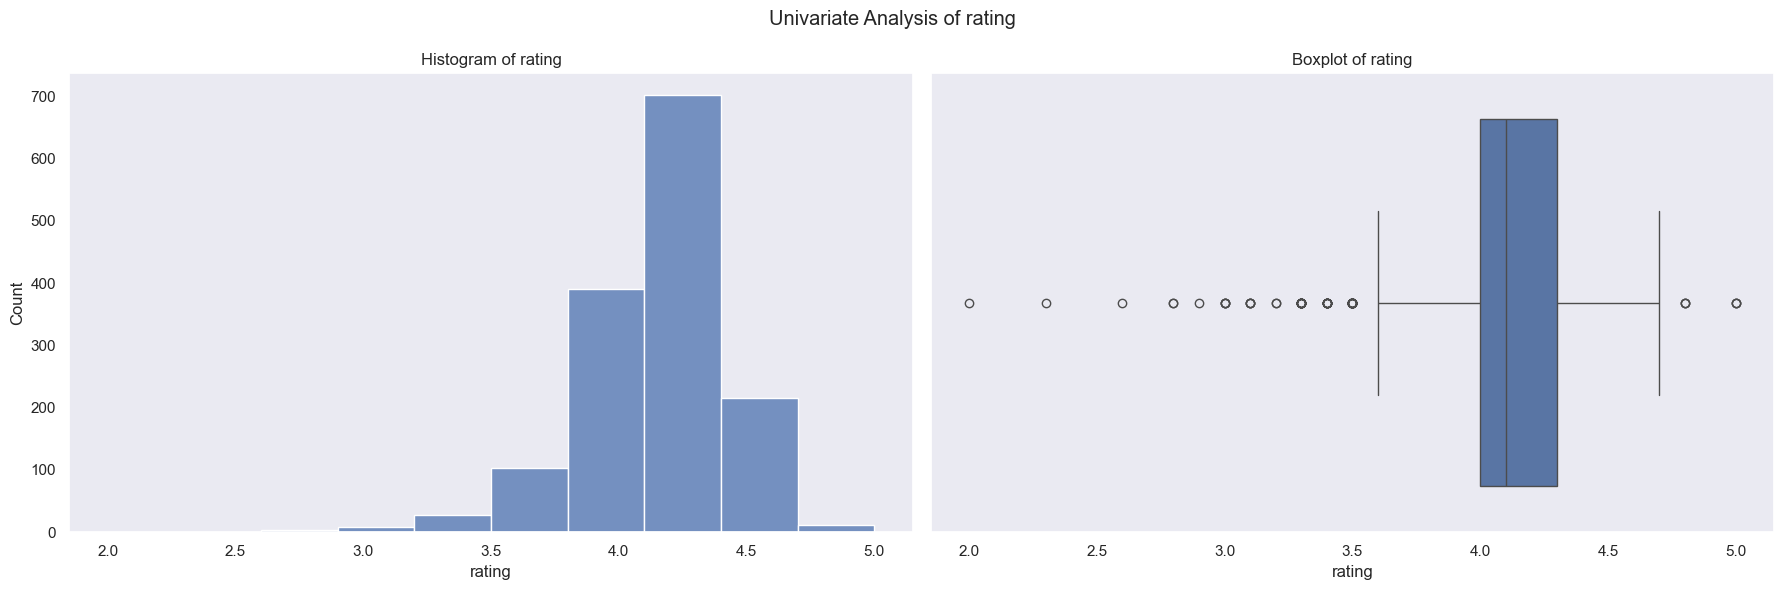

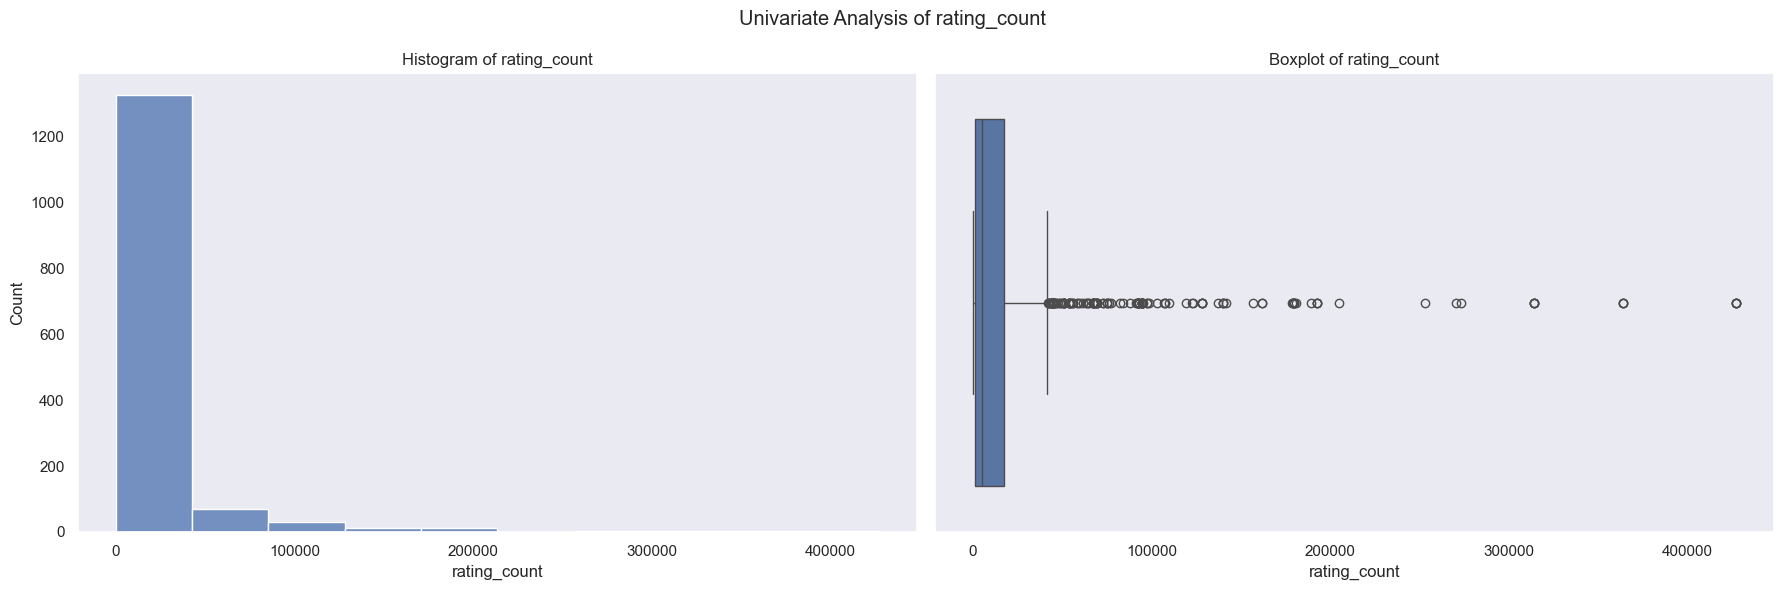

In [42]:
# Visualize distribution of numeric features
for col in num_cols:
    utils.plot_univariate(df_clean, col, "num")

**Key Findings**

- 

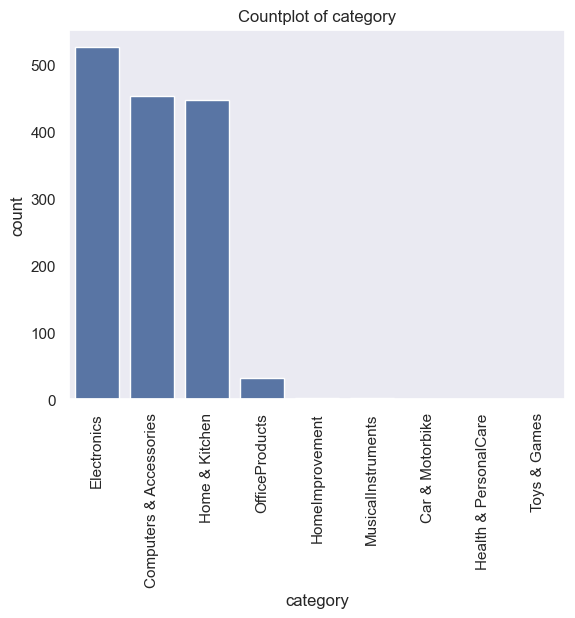

In [43]:
# Visualize distribution of categorical feature
utils.plot_univariate(df_clean, "category", "cat")

**Key Findings**

- 

### Bivariate Analysis

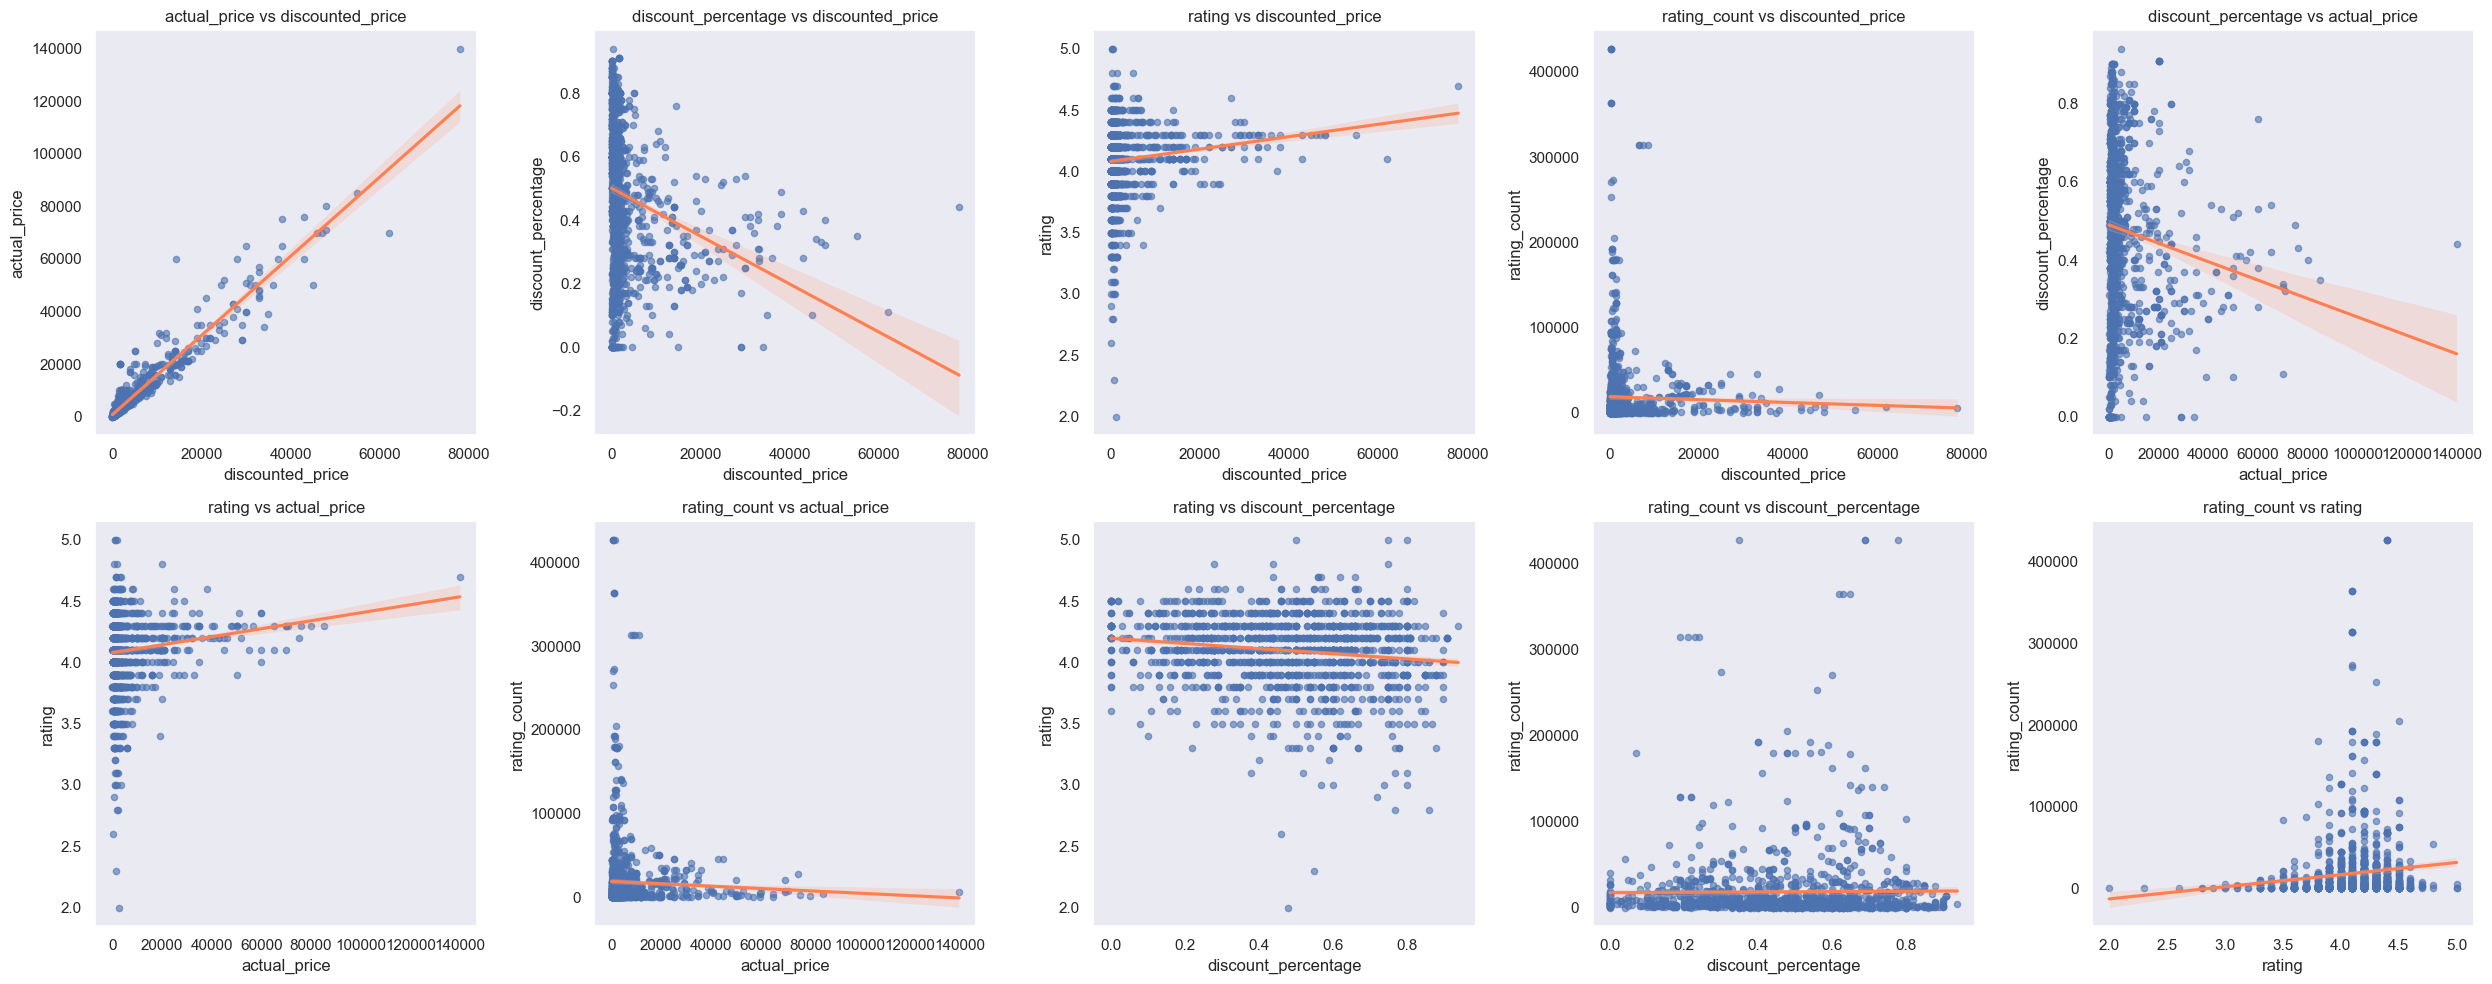

In [44]:
from itertools import combinations

# Generate unique pairs for numeric columns
pairs = list(combinations(num_cols, 2))  

# Set up figure layout
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

# Use scatter plots to visualize relationships between numeric features
# Add trend line to better view correlation
for ax, (x_col, y_col) in zip(axes, pairs):
    sns.regplot(
        data=df_clean, 
        x=x_col, 
        y=y_col, 
        ax=ax,
        scatter_kws={'s': 20, 'alpha': 0.6},
        line_kws={'color': 'coral'})
    ax.set_title(f"{y_col} vs {x_col}")

plt.tight_layout()
plt.show()

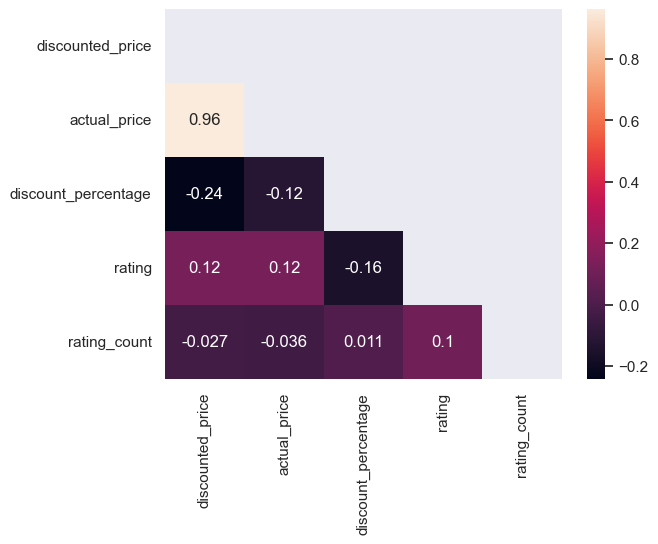

In [45]:
import numpy as np

correlations = df_clean[num_cols].corr()

# Create a mask for the upper triangle to avoid redundancy in the heatmap
mask = np.triu(np.ones_like(correlations, dtype=bool))

sns.heatmap(correlations, annot=True, mask=mask)
plt.show()

**Key Findings:**

- c

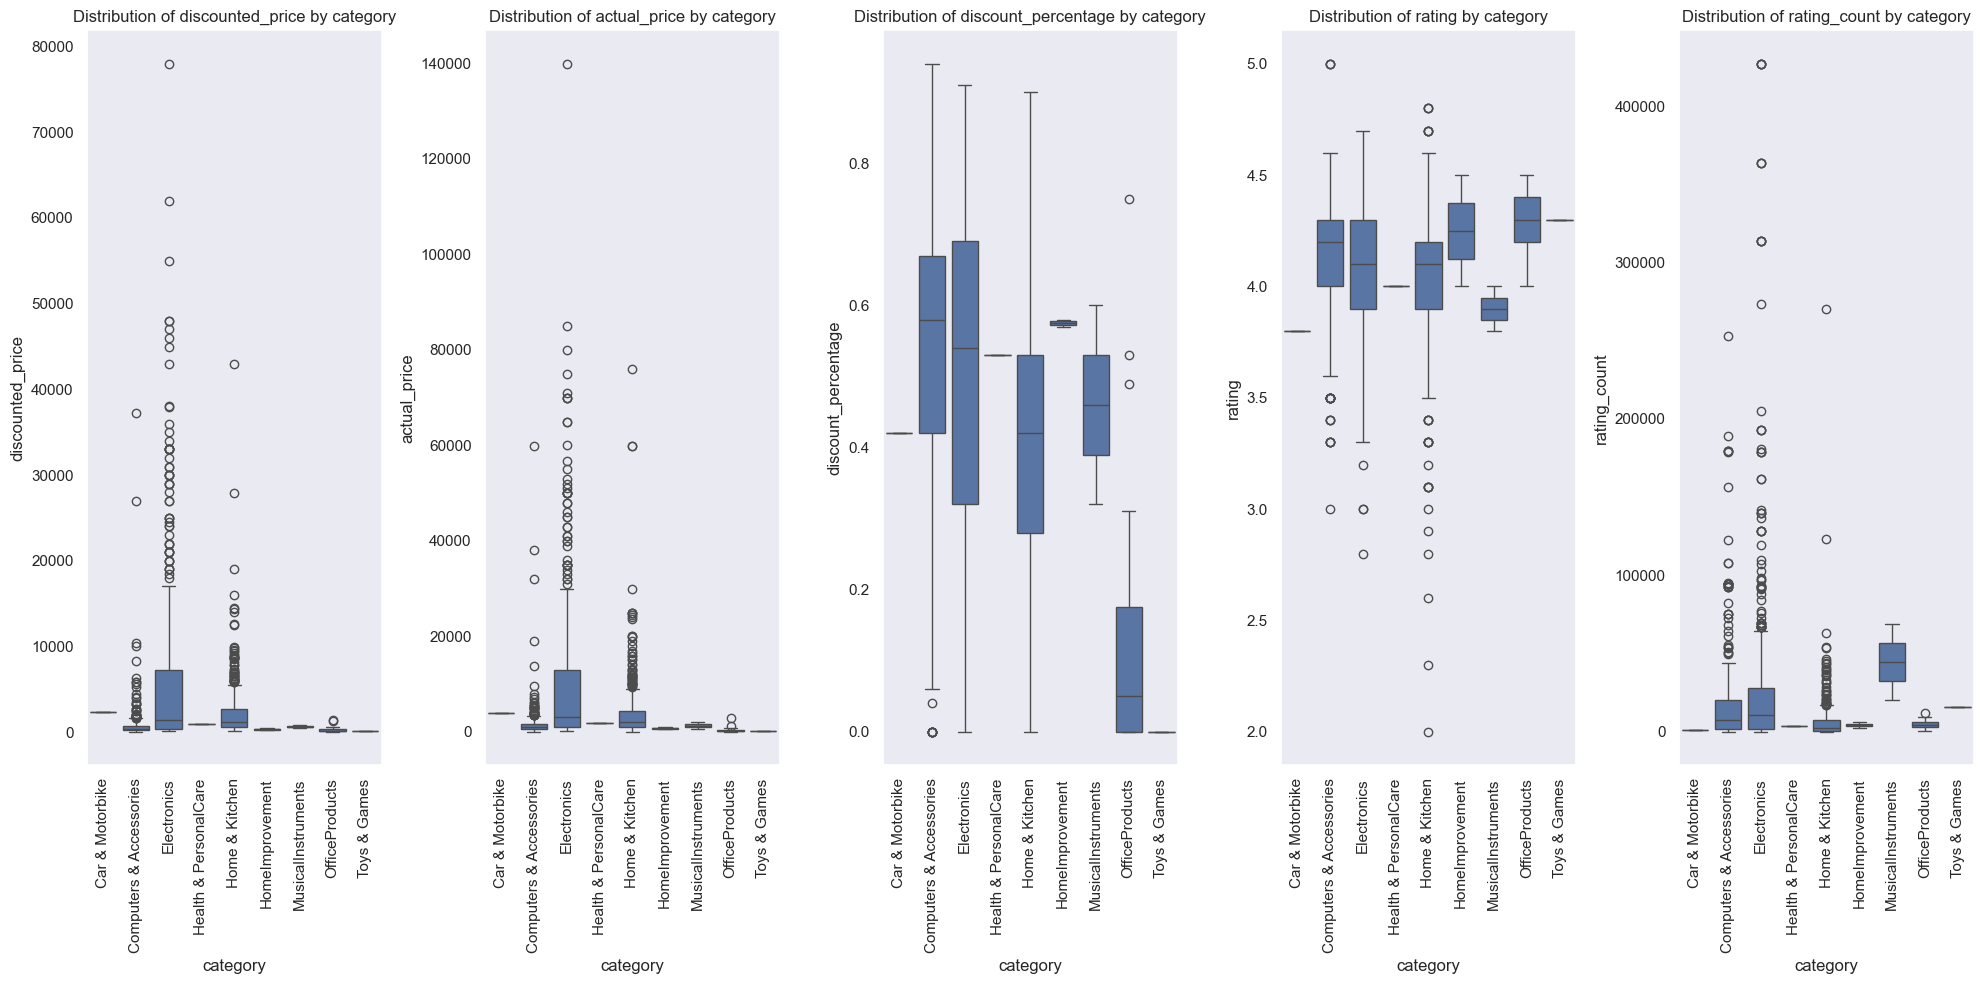

In [46]:
# Use box plots to visualize distribution of numeric features by category
fig, ax = plt.subplots(nrows=1, ncols=5, figsize=(20, 10))
ax = ax.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, x="category", y=col, ax=ax[i])
    ax[i].set_title(f"Distribution of {col} by category")
    ax[i].tick_params(axis='x', rotation=90)
    
plt.tight_layout()
plt.show()

**Key Findings:**

- c

## Insights and Hypothesis Formulation

### Insights
1. c
2. c
3. c
   
### Hypothesis
- 